# Rebuttal trivia-qa without context

* TLDR: performance only drops a bit, in the logs we now see real hallucinations

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'goatml'

In [6]:
# export to eval file
def get_vals(x):
    return x['mean'], x['mean']-x['bootstrap']['std_err'], x['mean']+x['bootstrap']['std_err']

def get_vals2(x):
    return x['means'], x['low'], x['high']


def get_perfs(metrics):
    data = []
    for method in metrics['performance']:
        mean, low, high = get_vals(metrics['performance'][method])
        data.append([method, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'means', 'low', 'high'])
    return df.set_index('method')

def plot_bar(df, color='C0', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    df.plot.bar(y='means', yerr=[df.means - df.low, df.high - df.means], color=color, ax=ax)

def get_uncertainty_df(metrics):
    data = []
    for method in metrics['uncertainty']:
        for metric in metrics['uncertainty'][method]:
            mean, low, high = get_vals(metrics['uncertainty'][method][metric])
            data.append([method, metric, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'metric', 'means', 'low', 'high'])
    
    df = df.set_index('method')

    def get_base_method(x):
        if 'p_false' in x:
            return 'p_false'
        elif 'p_ik' in x:
            return 'p_ik'
        elif 'regular_entropy' in x:
            return 'regular_entropy'
        elif 'cluster_assignment' in x:
            return x
        elif 'semantic_entropy' in x:
            return 'semantic_entropy'
        else:
            raise
    df['base_method'] = df.index.map(get_base_method)
    return df

def plot_bar_uncertainty(pdf, metric, remove='_UNANSWERABLE', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    tmp = pdf
    # filter out unanswerable
    if remove is not None:
        tmp = tmp[tmp.index.map(lambda x: remove not in x)]
    tmp = tmp.reset_index()
    tmp = tmp.set_index('metric').loc[metric]
    tmp = tmp.set_index('method')
    tmp = tmp.sort_values('base_method')

    b2c = {m:f'C{i}' for i, m in enumerate(tmp.base_method.unique())}
    basemethod2color = lambda x: b2c[x]

    plot_bar(tmp, color=tmp.base_method.map(basemethod2color), ax=ax)
    ax.grid(axis='y', zorder=-10, alpha=0.3)

In [4]:
def restore_file(wandb_id, filenames=['wandb-summary.json', 'config.yaml']):
    files_dir = 'notebooks/restored_files'    
    os.system(f'mkdir -p {files_dir}')

    run = api.run(f'goatml/semantic_uncertainty/{wandb_id}')
    # run = api.run(f'goatml/uncertainty/{wandb_id}')
    out = []

    for filename in filenames:
        
        path = f'{files_dir}/{filename}'
        os.system(f'rm -rf {path}')
        run.file(filename).download(root=files_dir, replace=True, exist_ok=False)
    
        if filename.endswith('.pkl'):
            with open(path, 'rb') as f:
                out.append(pickle.load(f))
        elif filename.endswith('.yaml'):
            with open(path, 'r') as f:
                out.append(yaml.safe_load(f))
        elif filename.endswith('.json'):
            with open(path, 'r') as f:
                out.append(json.load(f))
        else:
            raise

    return out

In [5]:
# The new runs are doing strict entailment _and_ condition on question,
runs = {
    'sy2g4uyv': '70b-trivia-qa',
    'ispvyuub': '70b-trivia-no-context',
    # NOTE: 70-bSQUAD RUNS ONLY HAVE 5 GENERATIONS !!
    '3dh1kja3': '70b-squad', # n2bhdjad
    'jky7j51k': '70b-squad-AO', # answerable only 'ttd2db7b''
    'zodwzypf': '70b-squad-AO-NC', # answerable only, no-context 'ttd2db7b''
# 
    '4qrza8sl': '7b-trivia-qa',
    'gk0phirh': '7b-trivia-no-context',
    '7nlpwfzq': '7b-squad', # n2bhdjad
    'bd90qu2n': '7b-squad-AO', # answerable only 'ttd2db7b''
    'cizk4p88': '7b-squad-AO-NC', # answerable only, no-context 'ttd2db7b''

    
}

all_configs, all_results = {}, {}

for wandb_id in runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)


Can we improve accuracy by instead voting the answer from the (high-temperature) clusters?

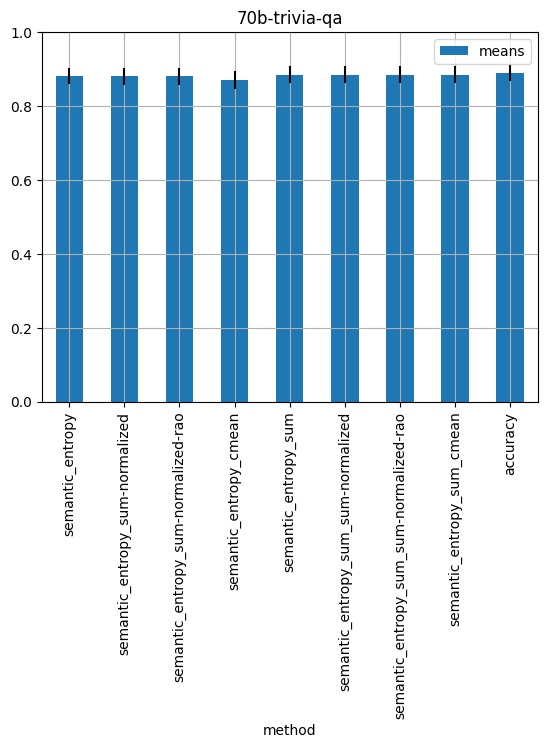

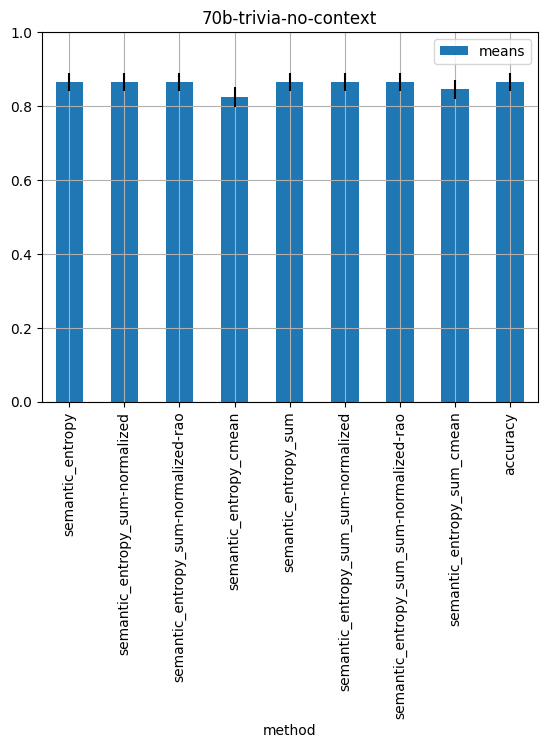

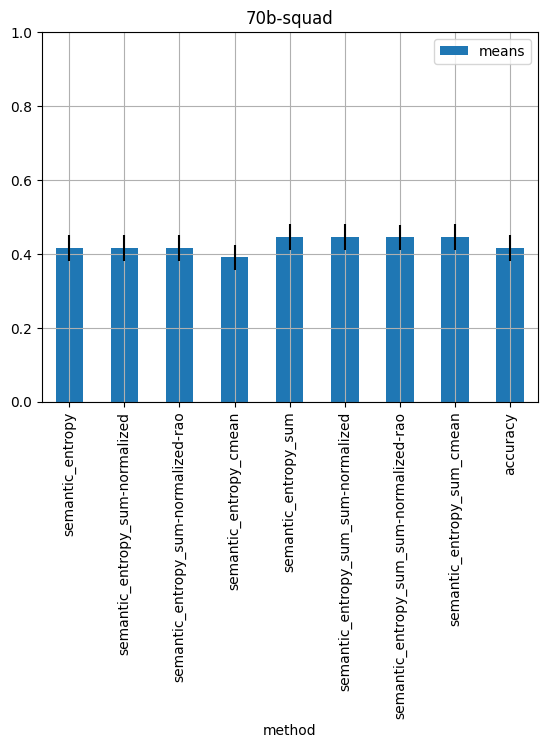

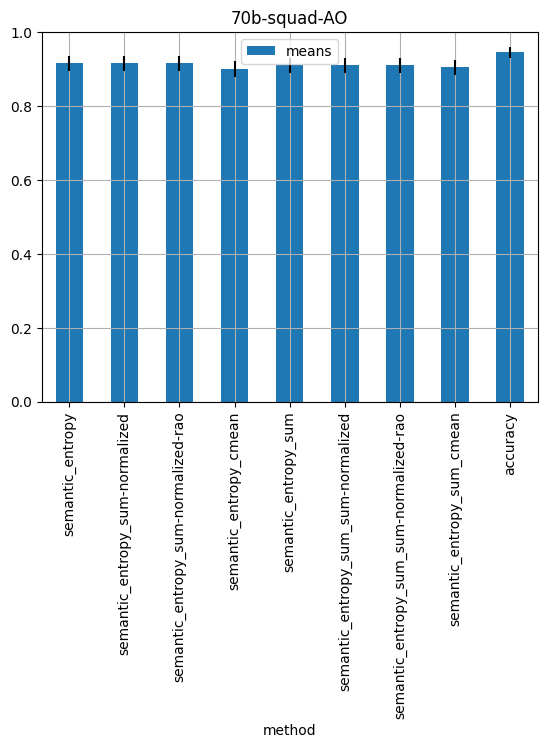

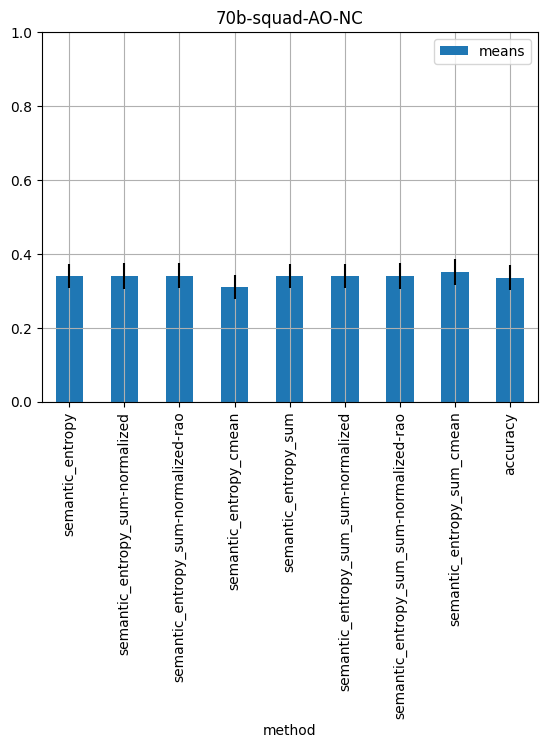

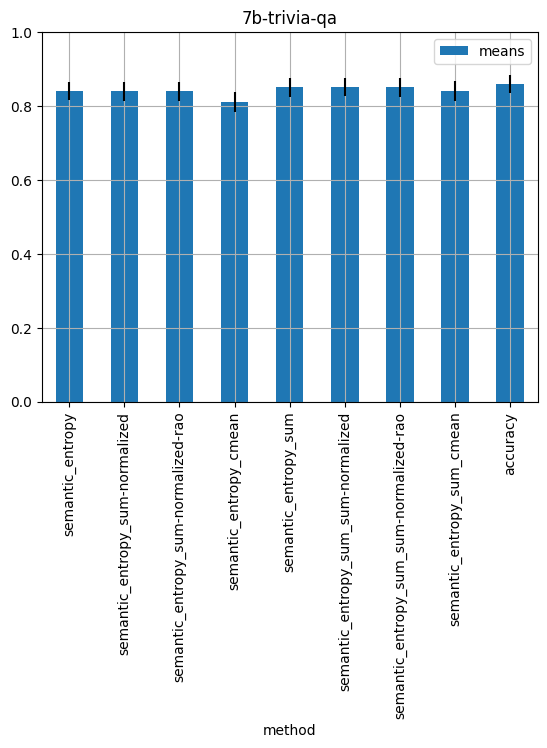

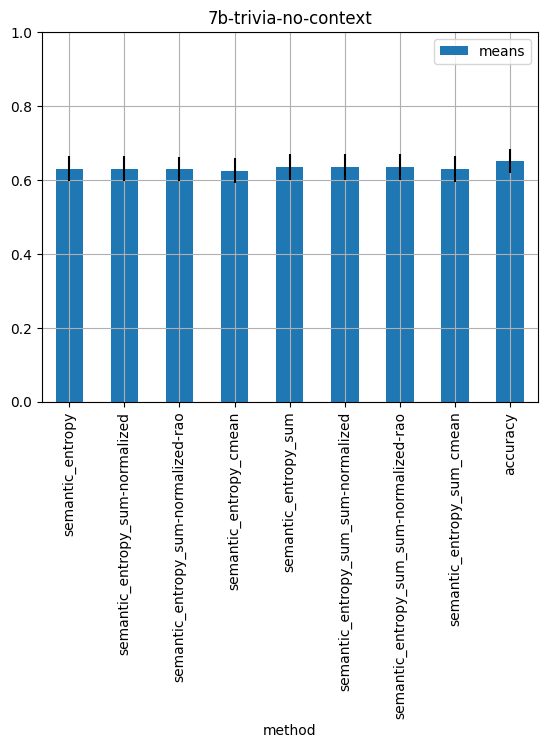

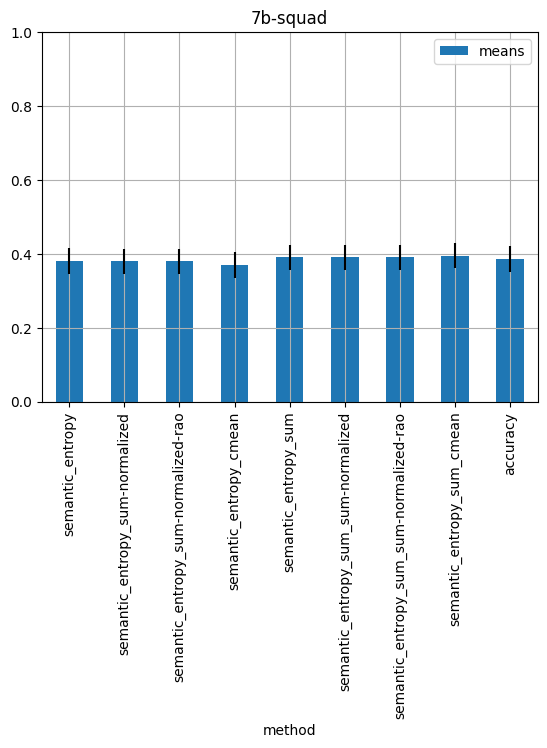

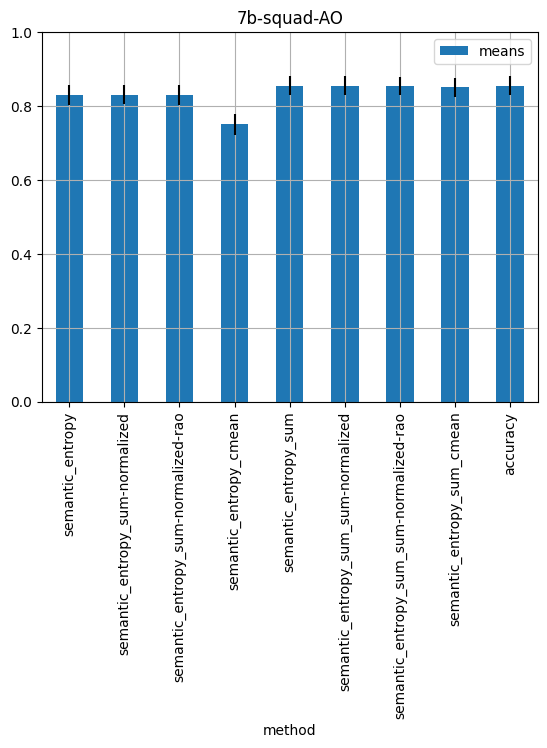

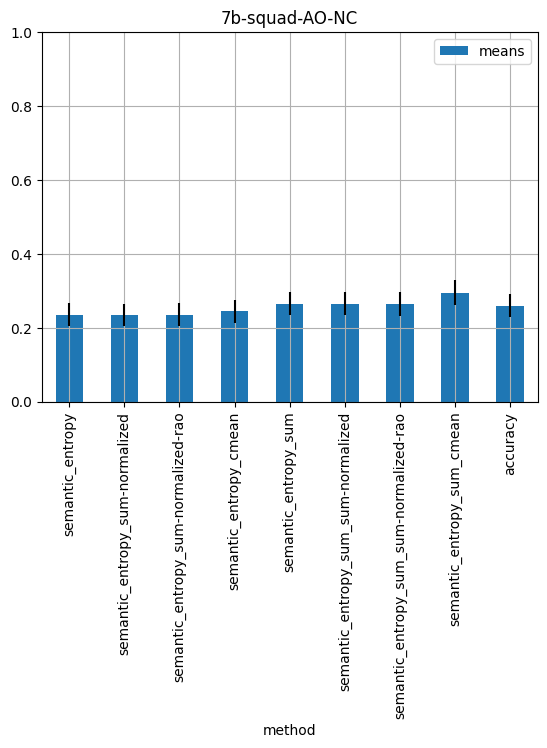

In [7]:
for wandb_id, run_name in runs.items():
    config = all_configs[wandb_id]
    results = all_results[wandb_id]

    df = get_perfs(results)
    plot_bar(df)
    plt.gca().set_title(run_name)
    plt.gca().grid()
    plt.gca().set_ylim(0, 1)


In [8]:
perfdf = {}
for wandb_id, run_name in runs.items():
    results = all_results[wandb_id]    
    perfdf[wandb_id] = get_perfs(results)

runids = list(perfdf.keys())
tmp = pd.DataFrame(perfdf[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(perfdf[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

perfdf = tmp.reset_index()

Text(0, 0.5, 'accuracy')

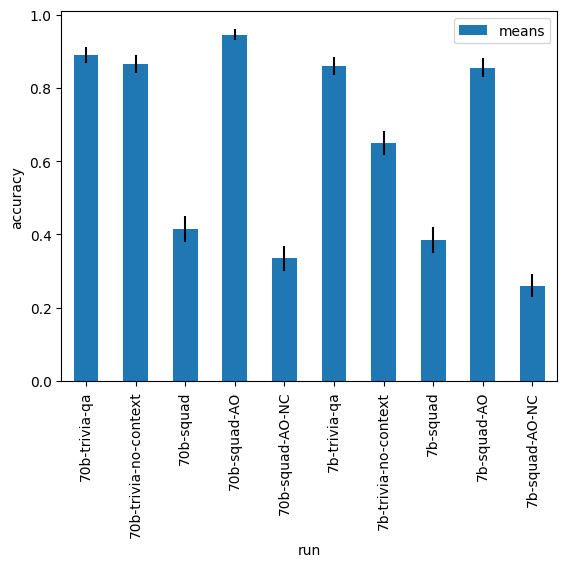

In [15]:
plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run'))
plt.gca().set_ylabel('accuracy')

In [23]:
tmp = perfdf.set_index('method').loc['accuracy']
tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
tmp.pivot(columns='model', index='dataset', values='means')


model,70b,7b
dataset,,
squad,0.415,0.385
squad-AO,0.945,0.855
squad-AO-NC,0.335,0.260
trivia-no-context,0.865,0.650
trivia-qa,0.890,0.860


* 7b largely performs very similar to 70b, usually a little worse (5-10%)
* Only big difference is for trivia-qa, where removing context leads to ~20 percent accuracy hit from ~85 to ~65 (this is not necessarily bad for us though)


In [25]:
metric_names = [
    'AUROC',
    'area_under_thresholded_accuracy',
    'mean_uncertainty',
    'accuracy_at_0.8_answer_fraction',
    'accuracy_at_0.9_answer_fraction',
    'accuracy_at_0.95_answer_fraction'
]

pdfs = {}
for wandb_id in runs:
    results = all_results[wandb_id]
    pdfs[wandb_id] = get_uncertainty_df(results)

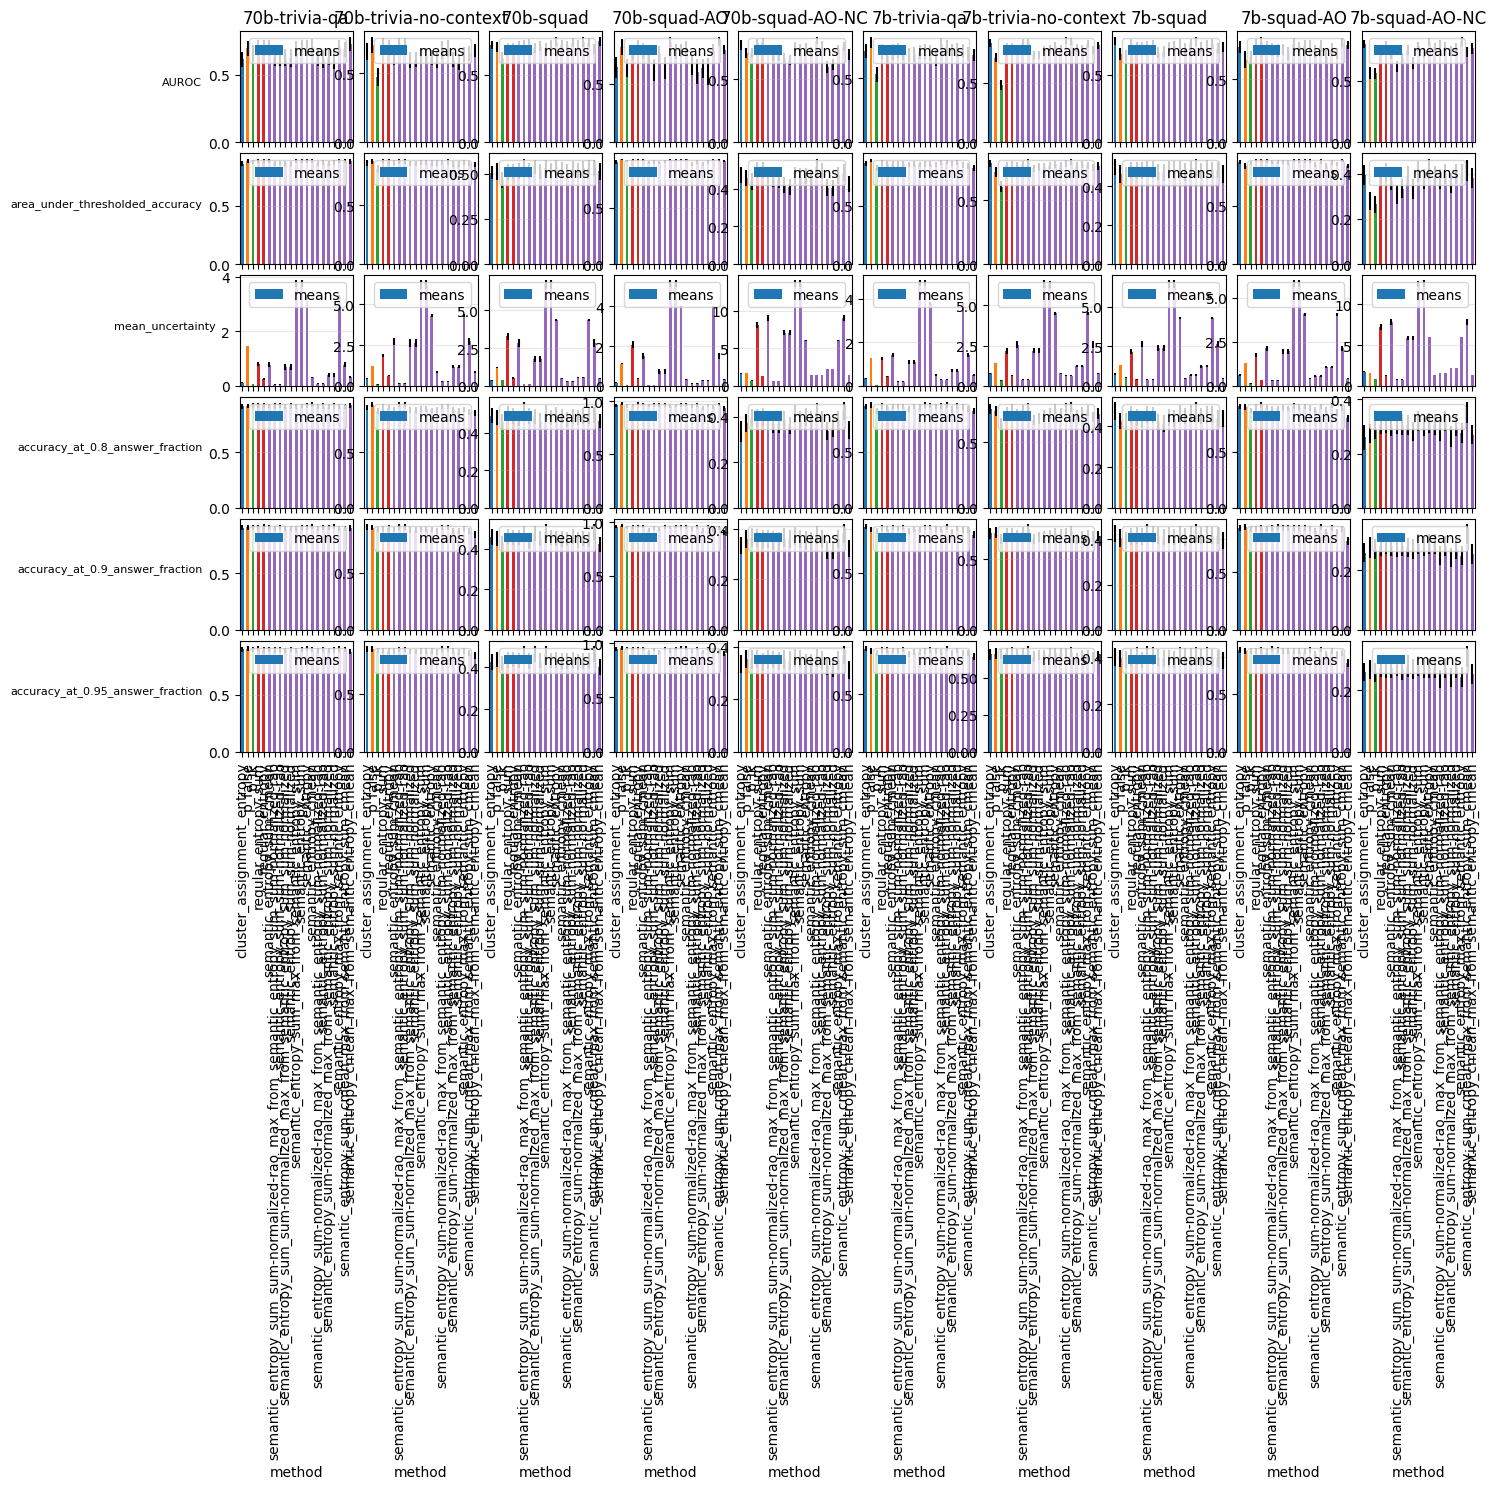

In [26]:
fig, axes_2d = plt.subplots(len(metric_names), len(runs), sharex=True, figsize=(15, 15), dpi=100)
# fig.suptitle(config['dataset']['value'] + ' '+ plt.gca().get_title())
for k, (name, axes) in enumerate(zip(list(metric_names), axes_2d)):

    for i, (ax, wandb_id) in enumerate(zip(axes, runs)):
        plot_bar_uncertainty(pdfs[wandb_id], name, ax=ax)

        if i == 0:
            ax.set_ylabel(name, fontsize=8, rotation=0, ha='right')

        if k == 0:
            ax.set_title(runs[wandb_id])


plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [27]:
runids = list(pdfs.keys())

tmp = pd.DataFrame(pdfs[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(pdfs[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

all_runs = tmp.reset_index()

/tmp/ipykernel_3591777/1764243749.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_3591777/1764243749.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


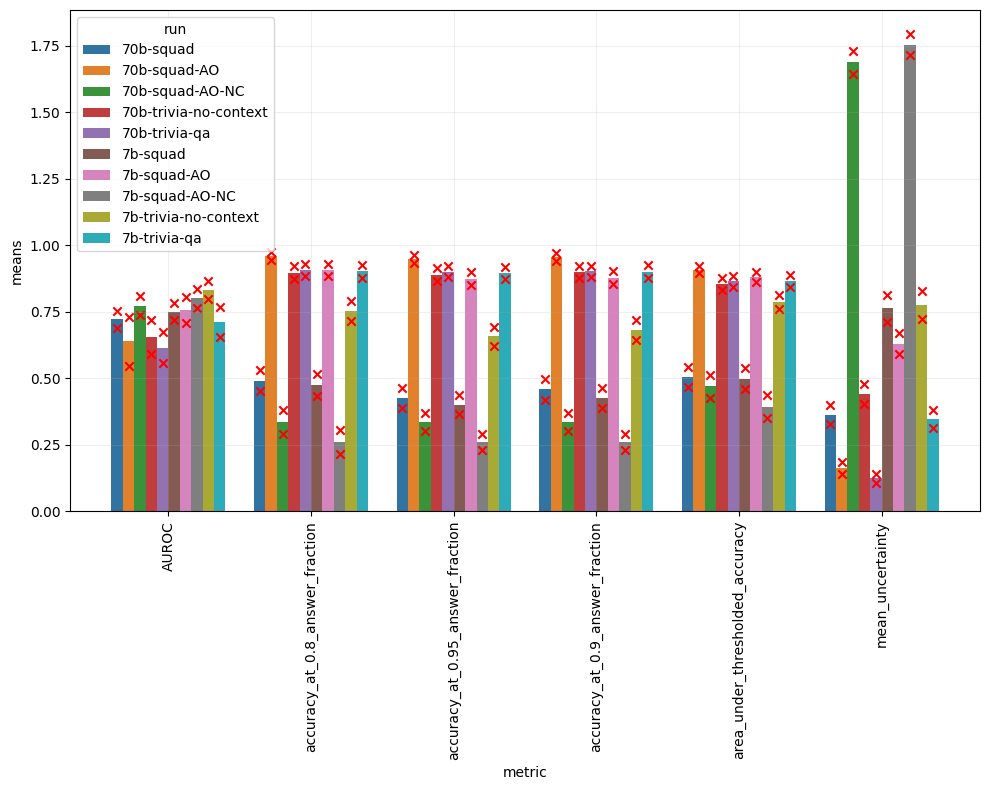

In [28]:
df2 = deepcopy(all_runs)
df2 = df2[all_runs.method == 'cluster_assignment_entropy']
df2 = df2.sort_values(['run', 'metric'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="metric",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_3591777/1448009336.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[all_runs.metric != 'mean_uncertainty']
/tmp/ipykernel_3591777/1448009336.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_3591777/1448009336.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


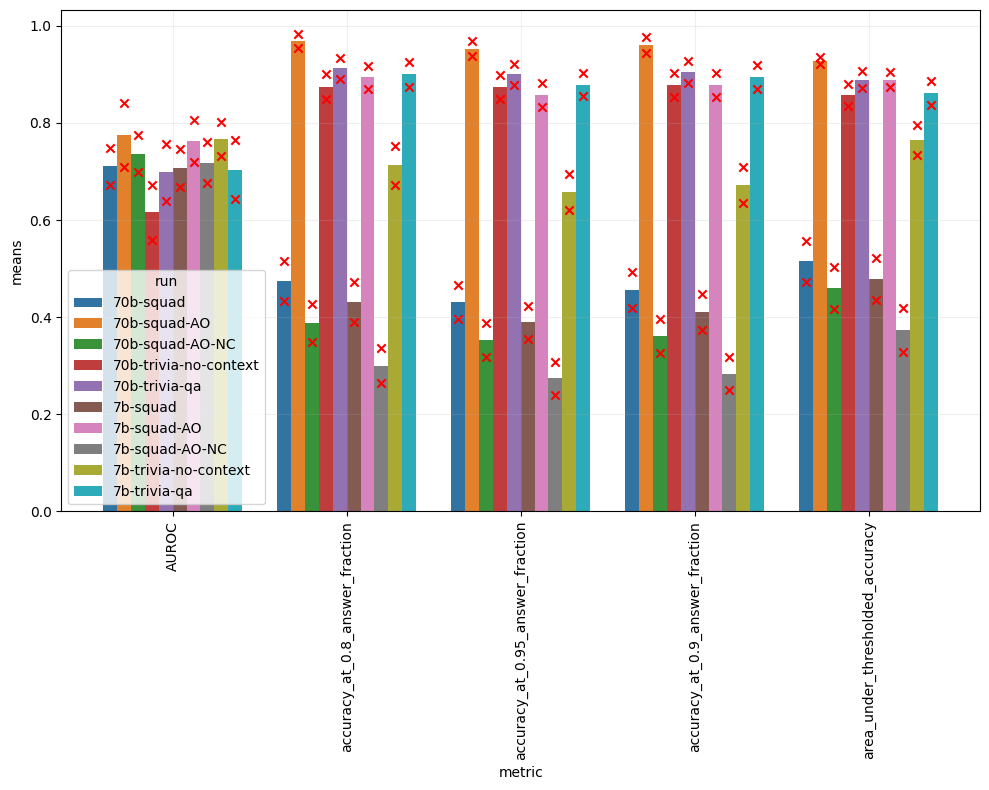

In [29]:
df2 = deepcopy(all_runs)
df2 = df2[all_runs.method == 'semantic_entropy_sum_cmean']
df2 = df2[all_runs.metric != 'mean_uncertainty']

df2 = df2.sort_values(['run', 'metric'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="metric",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_3591777/1528834326.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_3591777/1528834326.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


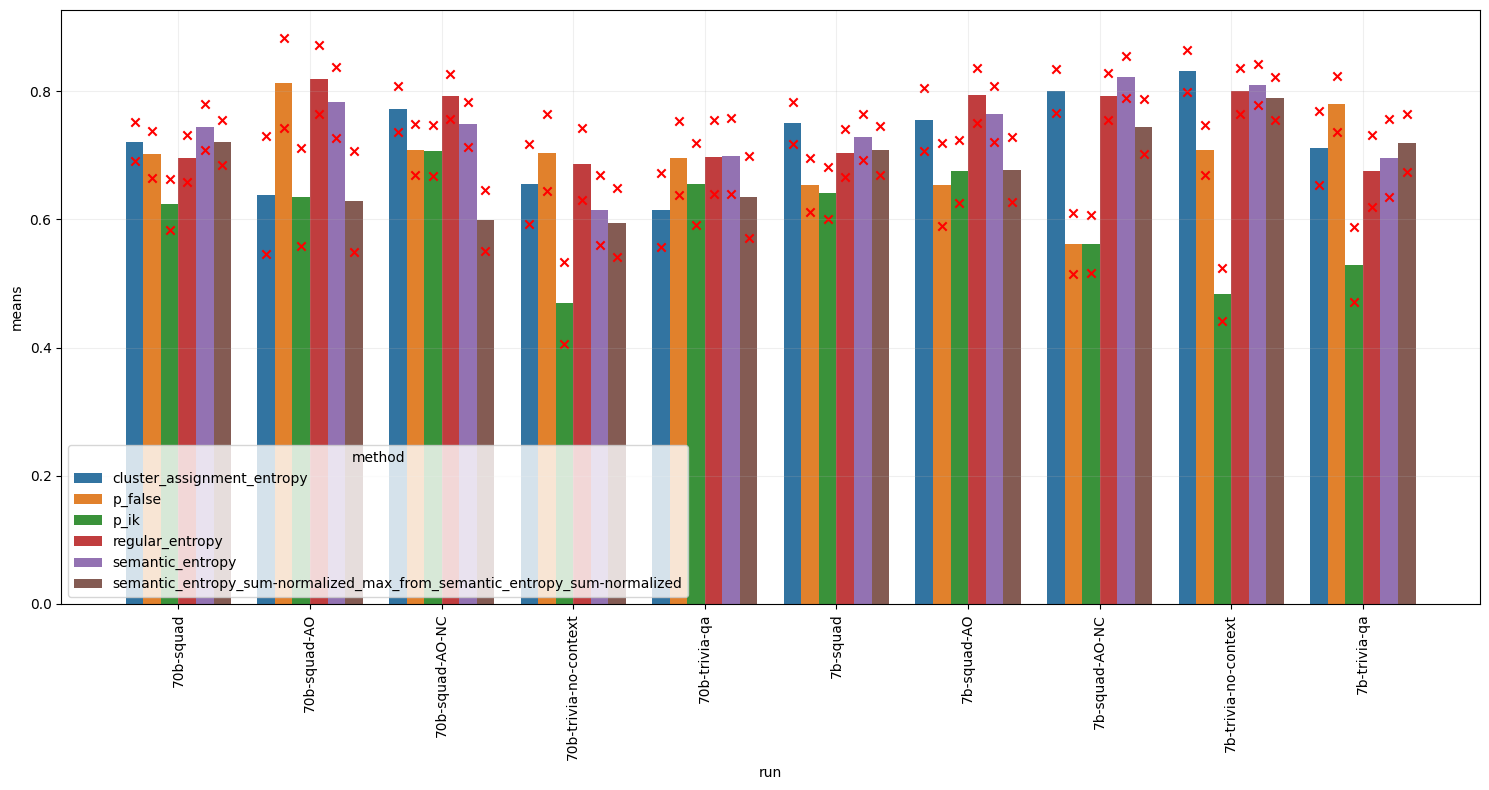

In [88]:
df2 = deepcopy(all_runs)
df2 = df2[df2.metric == 'AUROC']
main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized']

df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2.sort_values(['method', 'run'])

fig, ax = plt.subplots(1, 1, figsize=(15, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

In [90]:
df2.run.unique()

array(['70b-squad', '70b-squad-AO', '70b-squad-AO-NC',
       '70b-trivia-no-context', '70b-trivia-qa', '7b-squad',
       '7b-squad-AO', '7b-squad-AO-NC', '7b-trivia-no-context',
       '7b-trivia-qa'], dtype=object)

/tmp/ipykernel_3591777/1932603311.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_3591777/1932603311.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


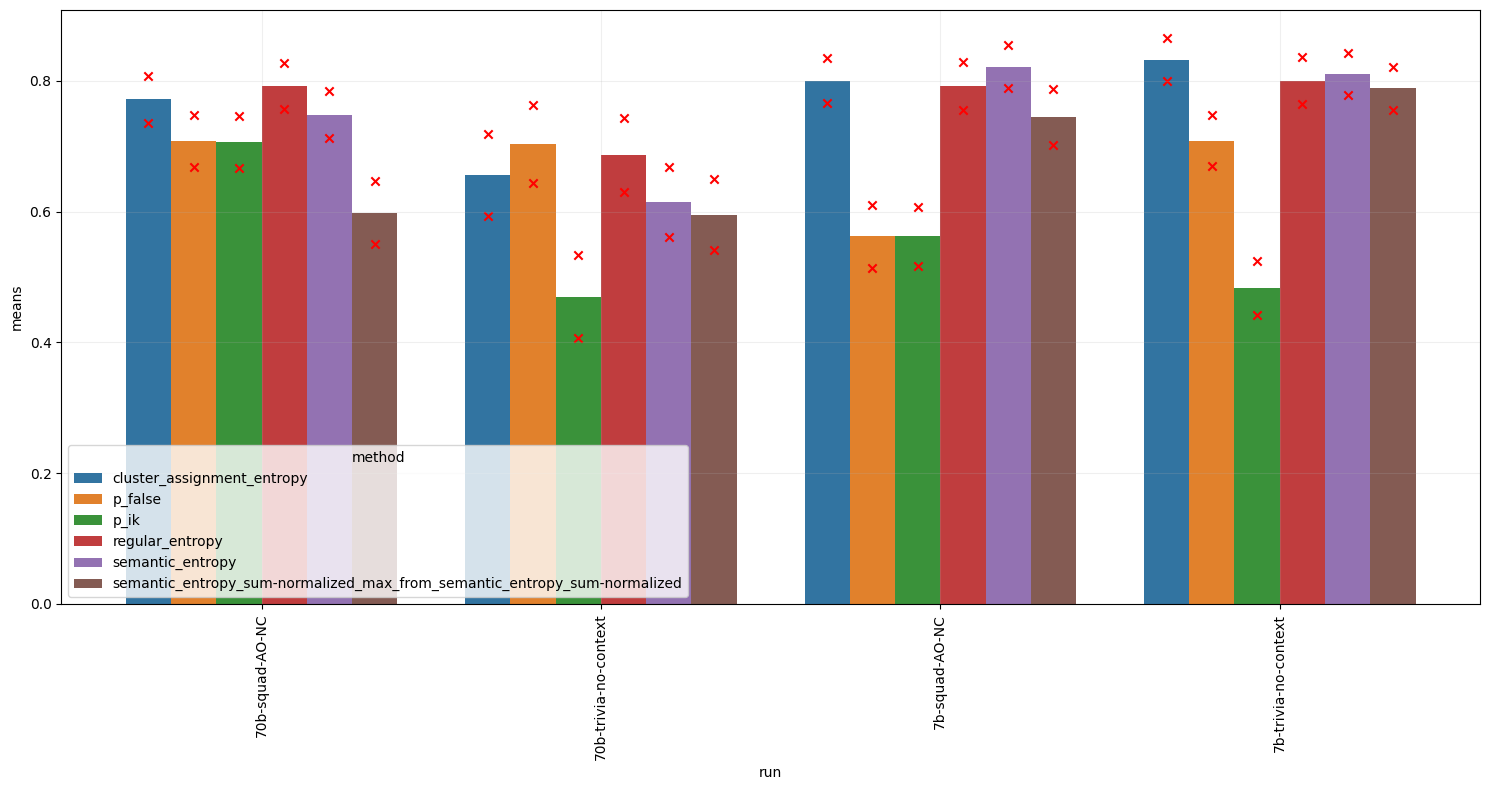

In [93]:
df2 = deepcopy(all_runs)
df2 = df2[df2.metric == 'AUROC']
main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized']

df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2[df2.run.map(lambda x: x in ['70b-squad-AO-NC', '70b-trivia-no-context', '7b-squad-AO-NC', '7b-trivia-no-context'])]

df2 = df2.sort_values(['method', 'run'])


fig, ax = plt.subplots(1, 1, figsize=(15, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

In [45]:
tmp = all_runs.set_index('metric').loc['AUROC']
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]


tmp

,method,means,low,high,base_method,run
metric,,,,,,
AUROC,p_false,0.695863,0.637643,0.754083,p_false,70b-trivia-qa
AUROC,cluster_assignment_entropy,0.614658,0.557200,0.672115,cluster_assignment_entropy,70b-trivia-qa
AUROC,regular_entropy,0.697395,0.639911,0.754879,regular_entropy,70b-trivia-qa
AUROC,semantic_entropy,0.699183,0.640432,0.757934,semantic_entropy,70b-trivia-qa
AUROC,semantic_entropy_max_from_semantic_entropy,0.702415,0.646267,0.758562,semantic_entropy,70b-trivia-qa
...,...,...,...,...,...,...
AUROC,semantic_entropy_sum_sum-normalized-rao,0.688799,0.649022,0.728577,semantic_entropy,7b-squad-AO-NC
AUROC,semantic_entropy_sum_sum-normalized-rao_max_fr...,0.619561,0.576643,0.662479,semantic_entropy,7b-squad-AO-NC
AUROC,semantic_entropy_sum_cmean,0.718165,0.676082,0.760248,semantic_entropy,7b-squad-AO-NC


In [ ]:
# for each run (and for each model) I would like to see the best methods

In [71]:
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
regular_entropy,0.745620,0.700845,0.790395
regular_entropy_sum,0.741832,0.696370,0.787294
semantic_entropy,0.740961,0.696370,0.785552
semantic_entropy_max_from_semantic_entropy,0.738627,0.695552,0.781702
semantic_entropy_sum_max_from_semantic_entropy_sum,0.736914,0.693153,0.780674
semantic_entropy_cmean_max_from_semantic_entropy_cmean,0.736013,0.695057,0.776969
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.733332,0.685350,0.781314
semantic_entropy_sum_cmean_max_from_semantic_entropy_sum_cmean,0.731688,0.689229,0.774148
semantic_entropy_sum-normalized-rao,0.728147,0.676881,0.779413


In [72]:
tmp[tmp.run.map(lambda x: x in ['70b-squad-AO-NC', '7b-squad-AO-NC', '70b-trivia-no-context', '7b-trivia-no-context'])].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.780085,0.738764,0.821407
semantic_entropy_sum-normalized-rao,0.768736,0.727759,0.809712
regular_entropy,0.767781,0.726796,0.808766
cluster_assignment_entropy,0.765117,0.723550,0.806685
regular_entropy_sum,0.760423,0.719765,0.801082
semantic_entropy_max_from_semantic_entropy,0.754411,0.713865,0.794958
semantic_entropy,0.748888,0.710124,0.787652
semantic_entropy_sum_max_from_semantic_entropy_sum,0.735970,0.695403,0.776537
semantic_entropy_cmean_max_from_semantic_entropy_cmean,0.734482,0.693446,0.775518


In [ ]:
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao

In [83]:
tmp[tmp.run.map(lambda x: x in ['70b-squad-AO-NC', '70b-trivia-no-context'])].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
regular_entropy_sum,0.743795,0.699603,0.787987
regular_entropy,0.739153,0.693335,0.784970
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.736008,0.688361,0.783656
semantic_entropy_sum-normalized-rao,0.725818,0.676860,0.774776
cluster_assignment_entropy,0.713863,0.664553,0.763173
p_false,0.706352,0.656484,0.756221
semantic_entropy_sum_cmean_max_from_semantic_entropy_sum_cmean,0.701022,0.657139,0.744905
semantic_entropy_sum_max_from_semantic_entropy_sum,0.692031,0.645682,0.738379
semantic_entropy_sum_sum-normalized-rao,0.691505,0.640344,0.742665


In [74]:
tmp[tmp.run.map(lambda x: x in ['7b-squad-AO-NC', '7b-trivia-no-context'])].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_max_from_semantic_entropy,0.824296,0.789945,0.858648
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.824162,0.789167,0.859157
cluster_assignment_entropy,0.816372,0.782546,0.850197
semantic_entropy,0.816202,0.783586,0.848819
semantic_entropy_sum-normalized-rao,0.811653,0.778658,0.844648
regular_entropy,0.796410,0.760258,0.832561
semantic_entropy_cmean_max_from_semantic_entropy_cmean,0.788497,0.751833,0.825160
semantic_entropy_sum_max_from_semantic_entropy_sum,0.779910,0.745124,0.814695
semantic_entropy_cmean,0.778703,0.743393,0.814013


In [76]:
tmp[tmp.run.map(lambda x: '7b' in x)].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao,0.774939,0.734717,0.815161
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.772291,0.731722,0.812861
cluster_assignment_entropy,0.770146,0.728573,0.811719
semantic_entropy,0.764118,0.722962,0.805274
semantic_entropy_max_from_semantic_entropy,0.757135,0.716232,0.798038
regular_entropy_sum,0.754061,0.713298,0.794824
regular_entropy,0.753247,0.711636,0.794857
semantic_entropy_sum_max_from_semantic_entropy_sum,0.749909,0.708739,0.791080
semantic_entropy_cmean_max_from_semantic_entropy_cmean,0.746739,0.708032,0.785446


In [75]:
tmp[tmp.run.map(lambda x: '7b' in x)].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao,0.774939,0.734717,0.815161
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.772291,0.731722,0.812861
cluster_assignment_entropy,0.770146,0.728573,0.811719
semantic_entropy,0.764118,0.722962,0.805274
semantic_entropy_max_from_semantic_entropy,0.757135,0.716232,0.798038
regular_entropy_sum,0.754061,0.713298,0.794824
regular_entropy,0.753247,0.711636,0.794857
semantic_entropy_sum_max_from_semantic_entropy_sum,0.749909,0.708739,0.791080
semantic_entropy_cmean_max_from_semantic_entropy_cmean,0.746739,0.708032,0.785446


In [87]:
tmp.set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
regular_entropy,0.745620,0.700845,0.790395
semantic_entropy,0.740961,0.696370,0.785552
cluster_assignment_entropy,0.725299,0.676670,0.773928
p_false,0.698123,0.647916,0.748329
p_ik,0.598173,0.546249,0.650097


In [86]:
tmp[tmp.run.map(lambda x: x in ['70b-squad-AO-NC', '70b-trivia-no-context', '7b-squad-AO-NC', '7b-trivia-no-context'])].set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
regular_entropy,0.767781,0.726796,0.808766
cluster_assignment_entropy,0.765117,0.723550,0.806685
semantic_entropy,0.748888,0.710124,0.787652
p_false,0.670939,0.624197,0.717681
p_ik,0.555662,0.507999,0.603325


In [84]:
tmp[tmp.run.map(lambda x: x in ['70b-squad-AO-NC', '70b-trivia-no-context'])].set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
regular_entropy,0.739153,0.693335,0.784970
cluster_assignment_entropy,0.713863,0.664553,0.763173
p_false,0.706352,0.656484,0.756221
semantic_entropy,0.681573,0.636661,0.726485
p_ik,0.588675,0.536770,0.640581


In [85]:
tmp[tmp.run.map(lambda x: x in ['7b-squad-AO-NC', '7b-trivia-no-context'])].set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
cluster_assignment_entropy,0.816372,0.782546,0.850197
semantic_entropy,0.816202,0.783586,0.848819
regular_entropy,0.796410,0.760258,0.832561
p_false,0.635526,0.591910,0.679141
p_ik,0.522649,0.479227,0.566070
